# Facial Keypoint Detection — Evaluación: CNN Baseline + Augmentation



## 1. Imports

In [ ]:
#%pip install torch torchvision

import os
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split


def pick_eval_device():
    if torch.cuda.is_available():
        try:
            t = torch.zeros(256, 3, 96, 96, device='cuda')  # ~27 MB, prueba realista
            del t
            torch.cuda.empty_cache()
            print(f'Usando CUDA (NVIDIA GPU): {torch.cuda.get_device_name(0)}')
            return torch.device('cuda')
        except RuntimeError as e:
            torch.cuda.empty_cache()
            print('GPU ocupada/sin memoria -> uso CPU. (' + str(e).splitlines()[0] + ')')
    else:
        print('CUDA no disponible, usando CPU.')
    return torch.device('cpu')

device = pick_eval_device()


Usando CUDA (NVIDIA GPU): NVIDIA GeForce RTX 2070


## 2. Configuración

In [ ]:

DATA_DIR       = r'C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data'
IMAGES_PATH    = os.path.join(DATA_DIR, 'preprocessed', 'images_50k.npy')
KEYPOINTS_PATH = os.path.join(DATA_DIR, 'preprocessed', 'keypoints_50k.npy')
MODEL_PATH     = os.path.join(DATA_DIR, 'best_baseline_augmented.pth')        # no pisa el baseline
LOSSES_PATH    = os.path.join(DATA_DIR, 'training_losses_baseline_augmented.pkl')

IMG_SIZE   = 96
BATCH_SIZE = 64
SEED       = 42
N_SHOW     = 8


## 3. Cargar datos y modelo

In [ ]:
class FacialKeypointDataset(Dataset):
    def __init__(self, images, keypoints):
        self.images    = torch.from_numpy(np.ascontiguousarray(images,    dtype=np.float32))
        self.keypoints = torch.from_numpy(np.ascontiguousarray(keypoints, dtype=np.float32))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.keypoints[idx]


class BaselineCNN(nn.Module):
    def __init__(self, num_keypoints=68):
        super().__init__()
        out_dim = num_keypoints * 2
        self.features = nn.Sequential(
            nn.Conv2d(3,   32, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128,256, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024), nn.ReLU(inplace=True),
            nn.Linear(1024, 256),          nn.ReLU(inplace=True),
            nn.Linear(256, out_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.regressor(self.features(x))



print('Abriendo datos en modo mmap...')
images_mm    = np.load(IMAGES_PATH,    mmap_mode='r')
keypoints_mm = np.load(KEYPOINTS_PATH, mmap_mode='r')
print(f'images:    {images_mm.shape}')
print(f'keypoints: {keypoints_mm.shape}')

N = images_mm.shape[0]
torch.manual_seed(SEED)
perm = torch.randperm(N).tolist()
train_size = int(0.8 * N)
val_idx = sorted(perm[train_size:])  


class MmapValDataset(Dataset):
    """Lee cada frame del .npy mapeado bajo demanda (no carga todo en RAM)."""
    def __init__(self, images_mm, keypoints_mm, indices):
        self.images_mm    = images_mm
        self.keypoints_mm = keypoints_mm
        self.indices      = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        j   = self.indices[i]
        img = torch.from_numpy(np.ascontiguousarray(self.images_mm[j],    dtype=np.float32))
        kp  = torch.from_numpy(np.ascontiguousarray(self.keypoints_mm[j], dtype=np.float32))
        return img, kp


val_dataset = MmapValDataset(images_mm, keypoints_mm, val_idx)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print()
print(f'Val: {len(val_dataset):,} frames  ({len(val_loader)} batches)')

# Cargar modelo
print(f'\nCargando modelo desde: {MODEL_PATH}')
model = BaselineCNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
model = model.to(device)
model.eval()
print('Modelo cargado. ✅')


Abriendo datos en modo mmap...
images:    (50000, 3, 96, 96)
keypoints: (50000, 136)

Val: 10,000 frames  (157 batches)

Cargando modelo desde: C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data\best_baseline_augmented.pth
Modelo cargado. ✅


## 4. Curva de pérdida

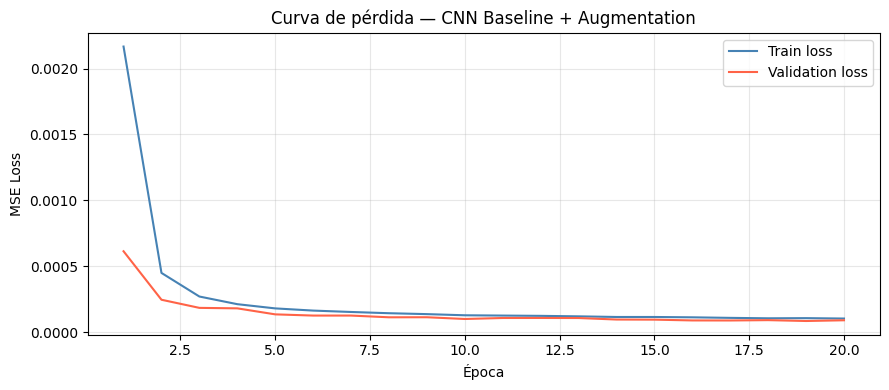

In [26]:
with open(LOSSES_PATH, 'rb') as f:
    losses = pickle.load(f)

epochs = range(1, len(losses['train']) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, losses['train'], label='Train loss',      color='steelblue')
ax.plot(epochs, losses['val'],   label='Validation loss', color='tomato')
ax.set_xlabel('Época'); ax.set_ylabel('MSE Loss')
ax.set_title('Curva de pérdida — CNN Baseline + Augmentation')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. RMSE en píxeles

RMSE global:            1.05 px
RMSE mínimo (keypoint): 0.82 px  (kp #35)
RMSE máximo (keypoint): 1.49 px  (kp #16)


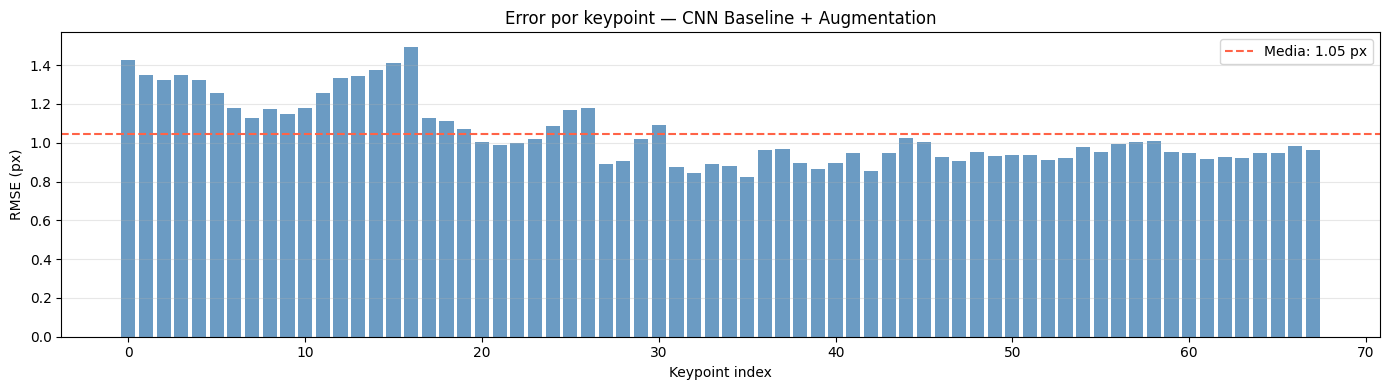

In [27]:
model.eval()
all_gt, all_pred = [], []

with torch.no_grad():
    for imgs, kps in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).cpu().numpy()
        all_gt.append(kps.numpy())
        all_pred.append(preds)

all_gt   = np.concatenate(all_gt,   axis=0) * IMG_SIZE
all_pred = np.concatenate(all_pred, axis=0) * IMG_SIZE

diff    = (all_gt - all_pred).reshape(-1, 68, 2)
dist_px = np.sqrt((diff ** 2).sum(axis=2))

rmse_per_kp  = dist_px.mean(axis=0)
rmse_overall = dist_px.mean()

print(f'RMSE global:            {rmse_overall:.2f} px')
print(f'RMSE mínimo (keypoint): {rmse_per_kp.min():.2f} px  (kp #{rmse_per_kp.argmin()})')
print(f'RMSE máximo (keypoint): {rmse_per_kp.max():.2f} px  (kp #{rmse_per_kp.argmax()})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(68), rmse_per_kp, color='steelblue', alpha=0.8)
ax.axhline(rmse_overall, color='tomato', linestyle='--', label=f'Media: {rmse_overall:.2f} px')
ax.set_xlabel('Keypoint index'); ax.set_ylabel('RMSE (px)')
ax.set_title('Error por keypoint — CNN Baseline + Augmentation')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 5.1 Percentiles del RMSE (p50, p90, p99)

In [ ]:

rmse_per_frame = np.sqrt((dist_px ** 2).mean(axis=1))   

p50 = np.percentile(rmse_per_frame, 50)   
p90 = np.percentile(rmse_per_frame, 90)
p99 = np.percentile(rmse_per_frame, 99)

print('RMSE por frame — estadisticos:')
print(f'  media : {rmse_per_frame.mean():.3f} px')
print(f'  std   : {rmse_per_frame.std():.3f} px')
print(f'  min   : {rmse_per_frame.min():.3f} px')
print(f'  max   : {rmse_per_frame.max():.3f} px')
print()
print('Percentiles del RMSE:')
print(f'  p50 (mediana): {p50:.3f} px')
print(f'  p90          : {p90:.3f} px')
print(f'  p99          : {p99:.3f} px')

RMSE por frame — estadisticos:
  media : 1.184 px
  std   : 0.371 px
  min   : 0.578 px
  max   : 9.987 px

Percentiles del RMSE:
  p50 (mediana): 1.115 px
  p90          : 1.570 px
  p99          : 2.386 px


## 5.2 Distribución del RMSE

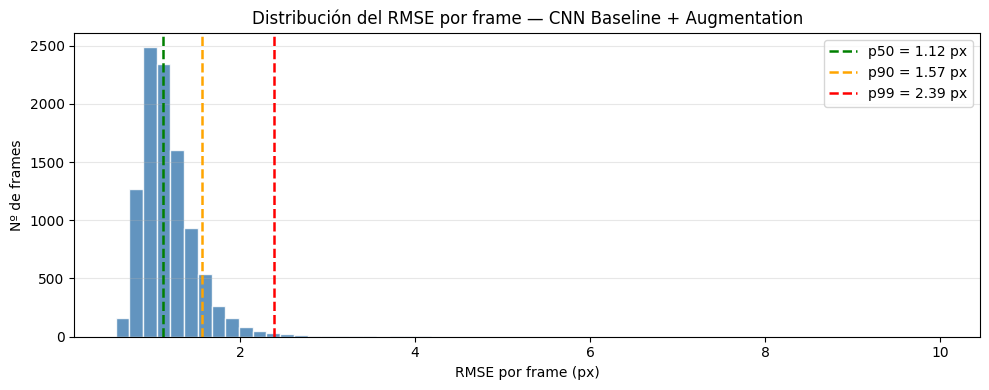

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rmse_per_frame, bins=60, color='steelblue', alpha=0.85, edgecolor='white')
for val, col, lab in [(p50, 'green', 'p50'), (p90, 'orange', 'p90'), (p99, 'red', 'p99')]:
    ax.axvline(val, color=col, linestyle='--', linewidth=1.8, label=f'{lab} = {val:.2f} px')
ax.set_xlabel('RMSE por frame (px)'); ax.set_ylabel('Nº de frames')
ax.set_title('Distribución del RMSE por frame — CNN Baseline + Augmentation')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 5.3 Los 5 mejores y los 5 peores frames



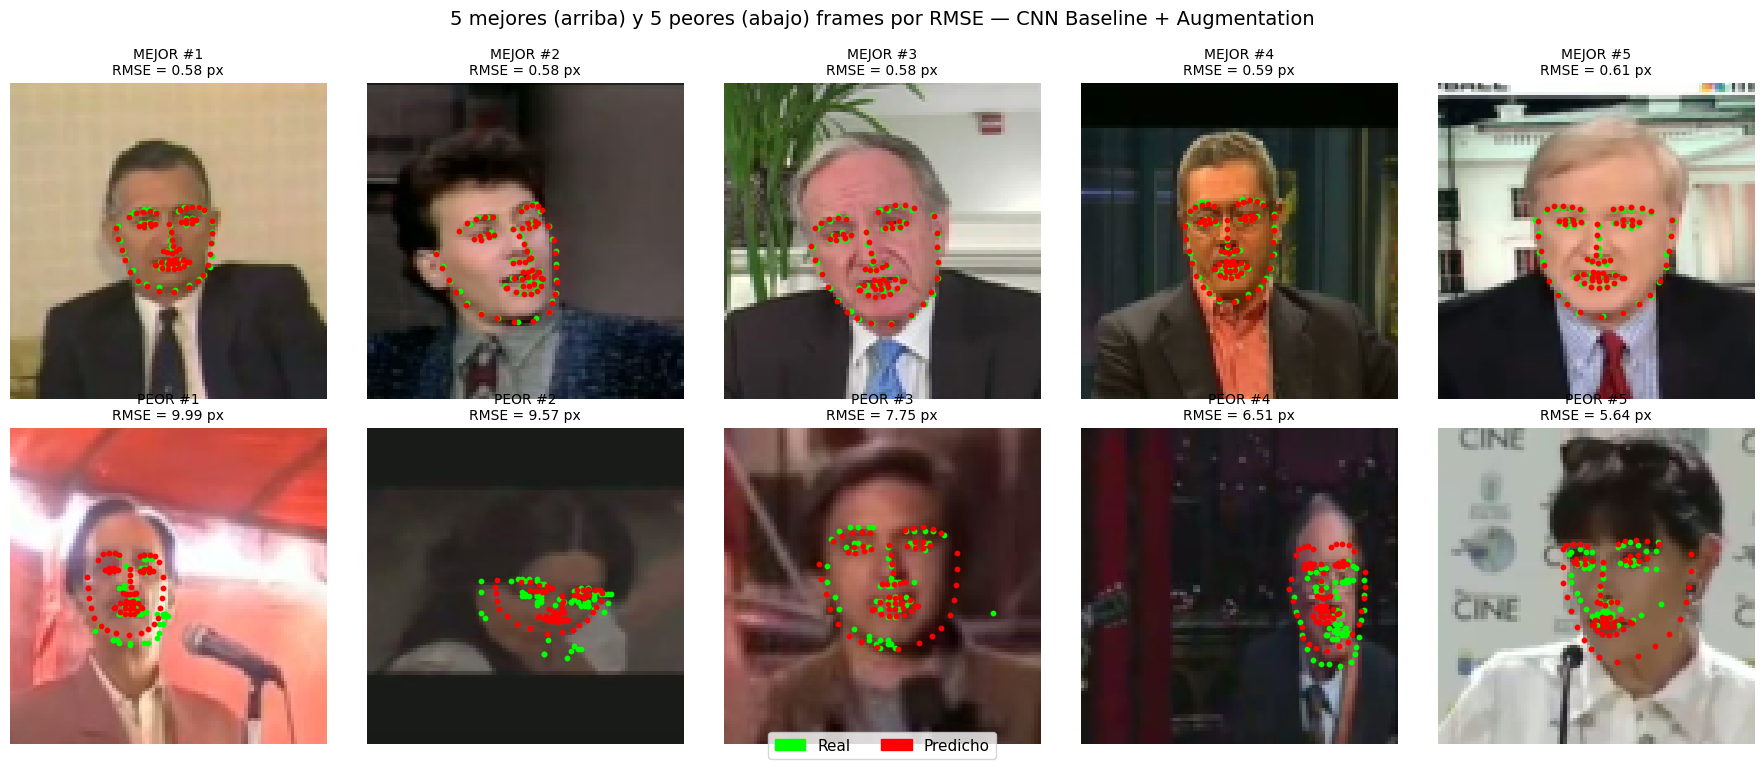

In [31]:
# Ordenar frames por RMSE: los 5 mejores (menor error) y los 5 peores (mayor error)
order     = np.argsort(rmse_per_frame)
best_idx  = order[:5]
worst_idx = order[-5:][::-1]   # peor primero

def _plot_frame(ax, i, title_prefix):
    img  = val_dataset[i][0].numpy().transpose(1, 2, 0)   # (H, W, 3)
    gt   = all_gt[i].reshape(-1, 2)     # ya en pixeles
    pred = all_pred[i].reshape(-1, 2)   # ya en pixeles
    ax.imshow(np.clip(img, 0, 1))
    ax.scatter(gt[:, 0],   gt[:, 1],   s=10, c='lime', zorder=5)
    ax.scatter(pred[:, 0], pred[:, 1], s=10, c='red',  zorder=6)
    ax.set_title(f'{title_prefix}\nRMSE = {rmse_per_frame[i]:.2f} px', fontsize=10)
    ax.axis('off')

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for col, i in enumerate(best_idx):
    _plot_frame(axes[0, col], i, f'MEJOR #{col + 1}')
for col, i in enumerate(worst_idx):
    _plot_frame(axes[1, col], i, f'PEOR #{col + 1}')

patch_gt   = mpatches.Patch(color='lime', label='Real')
patch_pred = mpatches.Patch(color='red',  label='Predicho')
fig.legend(handles=[patch_gt, patch_pred], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.01))
plt.suptitle('5 mejores (arriba) y 5 peores (abajo) frames por RMSE — CNN Baseline + Augmentation',
             fontsize=14, y=1.0)
plt.tight_layout(); plt.show()

## 5.4 Estadísticas adicionales


In [ ]:

print('Fracción de frames con RMSE por debajo de un umbral:')
for thr in [0.5, 1.0, 1.5, 2.0, 3.0]:
    pct = (rmse_per_frame <= thr).mean() * 100
    print(f'  <= {thr:>3.1f} px : {pct:5.1f} %')


all_dist = dist_px.reshape(-1)
print()
print('Percentiles del error por keypoint individual (px):')
for q in [50, 90, 99]:
    print(f'  p{q}: {np.percentile(all_dist, q):.3f} px')


worst_kp = np.argsort(rmse_per_kp)[-5:][::-1]
print()
print('Top-5 keypoints mas dificiles (RMSE medio):')
for k in worst_kp:
    print(f'  kp #{k:>2d}: {rmse_per_kp[k]:.3f} px')

Fracción de frames con RMSE por debajo de un umbral:
  <= 0.5 px :   0.0 %
  <= 1.0 px :  30.8 %
  <= 1.5 px :  87.1 %
  <= 2.0 px :  97.6 %
  <= 3.0 px :  99.6 %

Percentiles del error por keypoint individual (px):
  p50: 0.935 px
  p90: 1.842 px
  p99: 3.161 px

Top-5 keypoints mas dificiles (RMSE medio):
  kp #16: 1.494 px
  kp # 0: 1.425 px
  kp #15: 1.409 px
  kp #14: 1.373 px
  kp # 1: 1.351 px


## 6. Resumen final

In [35]:
print('=' * 50)
print('RESUMEN FINAL — CNN Baseline + Augmentation')
print('=' * 50)
print(f'Frames usados:    50,000  (train: 40,000  val: 10,000)')
print(f'Épocas:           {len(losses["train"])}')
print(f'Mejor val MSE:    {min(losses["val"]):.6f}')
print(f'RMSE global:      {rmse_overall:.2f} px')
print(f'Modelo:           {MODEL_PATH}')


RESUMEN FINAL — CNN Baseline + Augmentation
Frames usados:    50,000  (train: 40,000  val: 10,000)
Épocas:           20
Mejor val MSE:    0.000084
RMSE global:      1.05 px
Modelo:           C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data\best_baseline_augmented.pth
